In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Importing Packages and WandB Login

In [2]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForMultipleChoice,
    TrainingArguments,
    Trainer,
)

from sentence_transformers import SentenceTransformer

import wandb

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [3]:
# ============================================
# Reproducibility
# ============================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
wandb.login(
    key="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"
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

#### for the wandb login `wandb.login()` 
# Data Loading and Data information

The Smart MCQ Solver Challenge dataset consists of multiple-choice questions, where each question contains a prompt and five possible answer options (A–E). The training dataset also includes the correct answer label, while the test dataset contains only the questions and answer choices.

In this section, we load the datasets and create working copies that will be used throughout the notebook. The original datasets remain unchanged to preserve the raw data.

In [5]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

test_cc = test.copy()
train_cc = train.copy()
sample_submission_cc = sample_submission.copy()

print("=" * 60)
print("Training Dataset")
print("=" * 60)
print(f"Shape : {train_cc.shape}")
print("=" * 60)
print("Testing Dataset")
print("=" * 60)
print(f"Shape : {test_cc.shape}")
print("=" * 60)
print("Sample Submission")
print("=" * 60)
print(f"Shape : {sample_submission_cc.shape}")

Training Dataset
Shape : (2000, 8)
Testing Dataset
Shape : (500, 7)
Sample Submission
Shape : (500, 2)


>The dataset consists of a training split containing the correct answer labels and a separate test split without labels. A sample submission file is also provided to generate predictions in the required competition format.

In [6]:
print("=" * 60)
print("Training Dataset")
print("=" * 60)
display(train_cc.head())
print("=" * 60)
print("Test Dataset")
print("=" * 60)
display(test_cc.head())

Training Dataset


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


Test Dataset


,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


In [7]:
print("=" * 60)
print("Training Dataset information")
print("=" * 60)
display(train_cc.info())
print("=" * 60)
print("Test Dataset")
print("=" * 60)
display(test_cc.info())

Training Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


None

Test Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      500 non-null    int64 
 1   prompt  500 non-null    object
 2   A       500 non-null    object
 3   B       500 non-null    object
 4   C       500 non-null    object
 5   D       500 non-null    object
 6   E       500 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.5+ KB


None

### Observation --

The training dataset contains 2,000 multiple-choice questions, while the test dataset contains 500 unseen questions. Each question consists of a prompt and five candidate answer options (A–E). The training dataset additionally provides the correct answer label, which is used for supervised learning. The absence of missing values indicates that no imputation is required during preprocessing.

# EDA (Exploratory Data Analysis)
## Missing Value Analysis

In [8]:
print("Training Dataset Missing Values")
display(train_cc.isnull().sum())

Training Dataset Missing Values


id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

No missing values were found in either the training or testing dataset. Therefore, no imputation or missing value handling is required.

## Duplicate Analysis

In [9]:
train_duplicates = train_cc.drop(columns=["id"]).duplicated().sum()
print(f"Duplicate rows in Training Dataset : {train_duplicates}")

Duplicate rows in Training Dataset : 183


Observation

- After excluding the unique `id` column, the training dataset contains **183 duplicate records**.
- These duplicates indicate that some multiple-choice questions appear more than once in the dataset.
- Since repeated questions may provide additional learning signals and are part of the original competition dataset, they are retained rather than removed.
- Removing these duplicates could alter the original training distribution and may affect model performance on the competition benchmark.

## Target Class Distribution

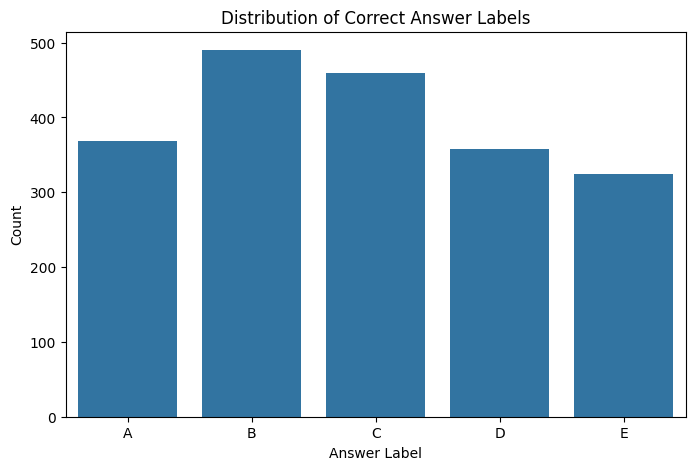

In [10]:
# =====================================================
# Target Distribution
# =====================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=train_cc,
    x="answer",
    order=sorted(train_cc["answer"].unique())
)

plt.title("Distribution of Correct Answer Labels")
plt.xlabel("Answer Label")
plt.ylabel("Count")

plt.show()

Observation

- The target labels are reasonably well distributed across the five answer classes.
- Labels **B** and **C** occur more frequently than the remaining classes, while **E** has the fewest samples.
- Although the dataset is not perfectly balanced, the class imbalance is relatively small and is unlikely to require additional balancing techniques such as oversampling or class weighting.
- Overall, the distribution suggests that the model will receive sufficient examples from every class during training.

## Prompt Length Distribution

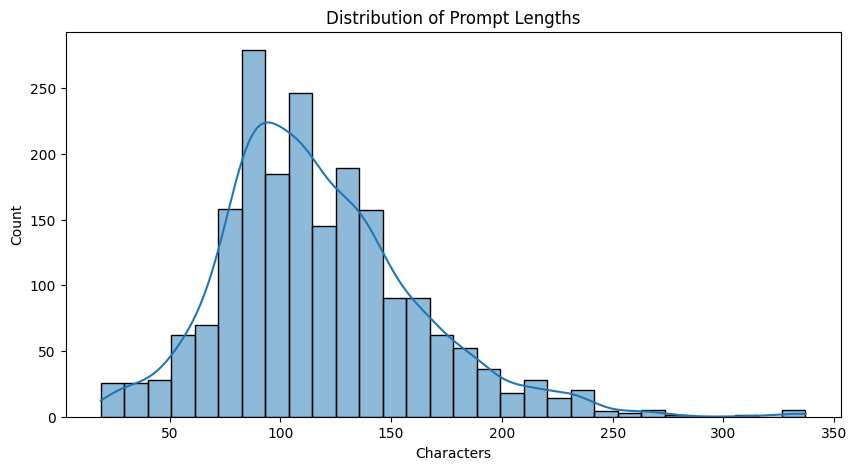

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_length, dtype: float64


In [11]:
train_cc["prompt_length"] = train_cc["prompt"].str.len()
plt.figure(figsize=(10,5))

sns.histplot(
    train_cc["prompt_length"],
    bins=30,
    kde=True
)

plt.title("Distribution of Prompt Lengths")

plt.xlabel("Characters")

plt.show()
print(train_cc["prompt_length"].describe())

Observation

- The average prompt length is approximately **118 characters**, with a median length of **111 characters**.
- Most questions fall within the range of **80–150 characters**, indicating that the majority of prompts are relatively concise.
- A small number of longer questions extend beyond **250 characters**, producing a slight right-skew in the distribution.
- Since prompt lengths remain within a manageable range, sequence truncation is unlikely to remove substantial information when an appropriate maximum sequence length is chosen.

## Option Length Analysis

In [12]:
for col in ["A","B","C","D","E"]:
    train_cc[f"{col}_length"] = train_cc[col].str.len()
option_lengths = train_cc[
    ["A_length","B_length","C_length","D_length","E_length"]
]

option_lengths.describe().T

,count,mean,std,min,25%,50%,75%,max
A_length,2000.0,164.0915,105.677145,1.0,86.0,143.0,234.0,472.0
B_length,2000.0,166.6165,113.829917,2.0,82.0,151.0,222.0,662.0
C_length,2000.0,167.2270,105.723674,2.0,88.0,158.0,224.0,530.0
D_length,2000.0,162.5635,104.116570,1.0,91.0,141.0,231.0,450.0
E_length,2000.0,164.2300,107.777712,2.0,84.0,144.0,224.0,587.0


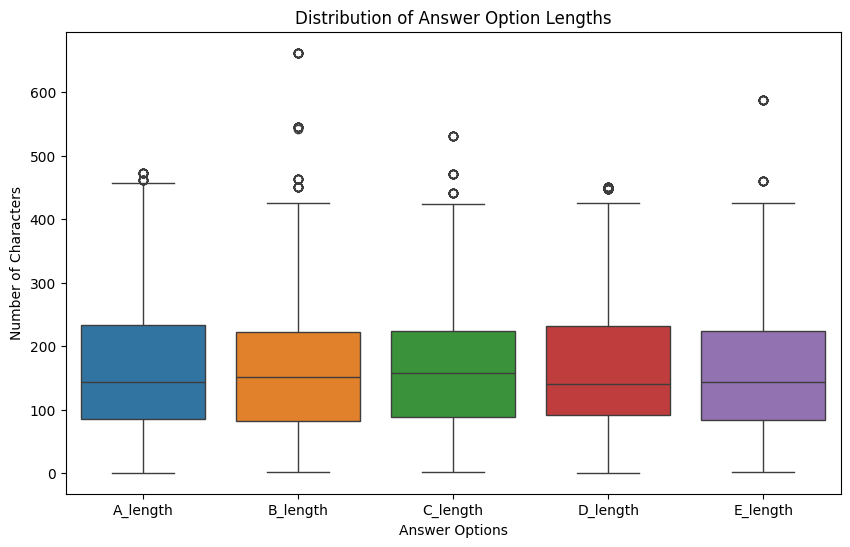

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(data=option_lengths)

plt.title("Distribution of Answer Option Lengths")
plt.xlabel("Answer Options")
plt.ylabel("Number of Characters")

plt.show()

Observation

- The average lengths of answer options are highly consistent across all five choices, ranging from approximately **162 to 167 characters**.
- This indicates that the dataset was carefully constructed, with answer options having comparable textual lengths.
- Since no option is consistently longer or shorter than the others, the model is less likely to learn superficial biases based solely on answer length.
- Consequently, the model will need to rely on the semantic relationship between the question and its answer choices rather than simple statistical cues.

## Random MCQ examples

In [14]:
sample = train_cc.sample(3, random_state=42)
display(sample)

,id,prompt,A,B,C,D,E,answer,prompt_length,A_length,B_length,C_length,D_length,E_length
1860,1861,Select the most accurate option: What is the p...,The propagation constant is a measure of the a...,The propagation constant is a real number that...,The propagation constant is a real number that...,The propagation constant is a complex number t...,The propagation constant is a complex number t...,D,97,104,125,115,118,128
353,354,Pick the best possible answer: What is the mos...,The pressure differential between the inside a...,The reduce in velocity resulting in an boost i...,The movement of air across the outside surface...,The use of cold water,Bernoulli's principle,E,124,70,56,68,21,21
1333,1334,Pick the best possible answer: What is the Kel...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,A,145,362,155,180,195,310


- Randomly sampled questions demonstrate that the dataset covers diverse topics, including science, philosophy, physics, astronomy, history, and general knowledge.
- The answer options are often semantically similar, requiring contextual understanding rather than simple keyword matching.
- This diversity highlights the need for models capable of capturing deeper semantic relationships between the question prompt and each candidate answer.

In [15]:
train_cc.drop(
    columns=["prompt_length","A_length","B_length","C_length","D_length","E_length"],inplace=True
)

### Observation
The exploratory analysis shows that the dataset is clean and well-structured, containing no missing values and only a moderate number of duplicate questions. The target labels are reasonably balanced across all five answer classes, reducing the risk of severe class imbalance during training. Prompt and answer option length analyses indicate that most samples fall within manageable sequence lengths, supporting the selected maximum sequence lengths used by the deep learning models. Finally, qualitative inspection of randomly sampled questions reveals that the dataset spans diverse scientific and general knowledge domains, with semantically similar answer choices that require contextual reasoning rather than simple lexical matching.

# Data Preprocessing
Data Preprocessing

│

├── 1. Label Encoding

├── 2. Text Data Validation

├── 3. Text Cleaning

└── 4. MCQ Formatting (Question-Option Pairs)



## Label Encoding

The target variable (`answer`) consists of categorical labels representing the correct answer option (`A`, `B`, `C`, `D`, and `E`). Since machine learning and deep learning models require numerical targets during training, these labels are converted into integer values using `LabelEncoder`.

The original `answer` column is preserved to maintain interpretability, while a new column named `label` is created for model training.

In [16]:
# =====================================================
# Label Encoding
# =====================================================

label_encoder = LabelEncoder()

train_cc["label"] = label_encoder.fit_transform(train_cc["answer"])

mapping = pd.DataFrame({
    "Answer Label": label_encoder.classes_,
    "Encoded Label": range(len(label_encoder.classes_))
})

display(mapping)

train_cc[["answer", "label"]].head()

,Answer Label,Encoded Label
0,A,0
1,B,1
2,C,2
3,D,3
4,E,4


,answer,label
0,B,1
1,A,0
2,C,2
3,B,1
4,A,0


Observation

The categorical target labels have been successfully converted into numerical values while preserving the original answer column. This numerical representation will be used during model training, whereas the original labels will later be recovered for generating the final competition submission.

## Text Data Validation
Before performing text preprocessing, all textual columns are explicitly converted to the `string` data type. Although the dataset already stores these columns as objects, converting them to strings ensures consistency and prevents unexpected errors during text cleaning, tokenization, and feature extraction.

This step guarantees that every question prompt and answer option can be processed uniformly by both classical machine learning and deep learning models.

In [17]:
# =====================================================
# Text Data Validation
# =====================================================

text_columns = ["prompt", "A", "B", "C", "D", "E"]

train_cc[text_columns] = train_cc[text_columns].astype(str)
display(train_cc[text_columns].dtypes)
print("=" * 60)
print("Additional validation")
print("=" * 60)
for column in text_columns:
    print(f"{column}: {type(train_cc[column].iloc[0]).__name__}")

prompt    object
A         object
B         object
C         object
D         object
E         object
dtype: object

Additional validation
prompt: str
A: str
B: str
C: str
D: str
E: str


Observation

>All textual columns were successfully converted to string format. This ensures a consistent data representation across the dataset and avoids type-related issues during subsequent preprocessing steps such as text cleaning, vectorization, and tokenization.

## Text Cleaning

To preserve the semantic and grammatical structure of the questions, only minimal text preprocessing is performed.

Unlike traditional NLP pipelines, aggressive preprocessing techniques such as lowercasing, punctuation removal, stop-word removal, stemming, and lemmatization are intentionally avoided. This is because pretrained transformer models benefit from retaining the original sentence structure and punctuation.

The cleaning process is therefore limited to:

- Removing leading and trailing whitespace.
- Replacing multiple consecutive spaces with a single space.
- Removing unnecessary newline and tab characters.

This lightweight preprocessing ensures consistency while preserving the contextual information required by both classical machine learning and transformer-based models.

In [18]:
import re

def clean_text(text):

    text = text.replace("\n", " ")
    text = text.replace("\t", " ")

    text = re.sub(r"\s+", " ", text)

    return text.strip()

sample_text = "  This   is   a\t sample\ntext.   "

print("Before Cleaning:")
print(repr(sample_text))

print("\nAfter Cleaning:")
print(repr(clean_text(sample_text)))

Before Cleaning:
'  This   is   a\t sample\ntext.   '

After Cleaning:
'This is a sample text.'


This is the function for the Text cleaning which we will use later inside each models pipeline.

## MCQ Formatting
For every multiple-choice question, five Question–Option pairs are created:

- Prompt + Option A
- Prompt + Option B
- Prompt + Option C
- Prompt + Option D
- Prompt + Option E

This representation allows every candidate answer to be evaluated independently and can be reused across all three models developed in this project.

In [19]:
def create_question_option_pair(question, option):
    return (
        f"Question: {question}\n"
        f"Answer: {option}"
    )

print("=" * 60)
print("Test for the create_question_option_pair function")
print("=" * 60)

sample_row = train_cc.iloc[0]

print(
    create_question_option_pair(
        sample_row["prompt"],
        sample_row["A"]
    )
)

Test for the create_question_option_pair function
Question: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
Answer: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.


# Train/Validation Split

Training Dataset

        │
        ▼
Train / Validation Split

        │
        ├────────► Training Set
        │
        └────────► Validation Set
                         │
                         ▼
                  Model Evaluation

To evaluate the performance of different models fairly, the training dataset is divided into a training subset and a validation subset.

The validation set is used exclusively for model evaluation and hyperparameter tuning, while the Kaggle test dataset is reserved for the final competition submission.

A stratified split is performed to preserve the original distribution of the target classes across both subsets.

In [20]:
x = train_cc.drop(columns=["answer", "label"])
y = train_cc["label"]

x_train, x_valid, y_train, y_valid = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("=" * 60)
print("Training Set")
print("=" * 60)
print(f"Features : {x_train.shape}")
print(f"Labels   : {y_train.shape}")

print()

print("=" * 60)
print("Validation Set")
print("=" * 60)
print(f"Features : {x_valid.shape}")
print(f"Labels   : {y_valid.shape}")

Training Set
Features : (1600, 7)
Labels   : (1600,)

Validation Set
Features : (400, 7)
Labels   : (400,)


In [21]:
train_distribution = y_train.value_counts(normalize=True).sort_index()
valid_distribution = y_valid.value_counts(normalize=True).sort_index()

distribution = pd.DataFrame({
    "Training (%)": (train_distribution * 100).round(2),
    "Validation (%)": (valid_distribution * 100).round(2)
})

display(distribution)

,Training (%),Validation (%)
label,,
0,18.44,18.50
1,24.50,24.50
2,22.94,23.00
3,17.94,17.75
4,16.19,16.25


Observation

The training dataset was successfully divided into an 80:20 training-validation split using stratified sampling. This ensures that the proportion of each answer class remains nearly identical across both subsets, enabling a fair evaluation of model performance while minimizing sampling bias.

# Model 1 (TF-IDF Baseline Model)

The first model serves as a traditional information retrieval baseline. Instead of learning semantic representations, TF-IDF converts text into sparse vector representations based on term importance. The similarity between the question and each candidate answer is then measured using cosine similarity.

For every question, the answer options are ranked according to their cosine similarity scores, and the three highest-scoring options are selected as the predicted Top-3 answers.

In [22]:
#creating model specific data
train_tfidf = x_train.copy()
valid_tfidf = x_valid.copy()

train_tfidf["label"] = y_train.values
valid_tfidf["label"] = y_valid.values

In [23]:
#Generating the question option pairs
def generate_option_pairs(row):
    return {
        "A": create_question_option_pair(row["prompt"], row["A"]),
        "B": create_question_option_pair(row["prompt"], row["B"]),
        "C": create_question_option_pair(row["prompt"], row["C"]),
        "D": create_question_option_pair(row["prompt"], row["D"]),
        "E": create_question_option_pair(row["prompt"], row["E"]),
    }

pairs = generate_option_pairs(train_tfidf.iloc[0])

for option, text in pairs.items():
    print("=" * 60)
    print(option)
    print(text)

A
Question: Select the most accurate option: What is Modified Newtonian Dynamics (MOND)? from the following choices.
Answer: MOND is a principle that explains the behavior of light in the presence of strong gravitational fields. It is an alternative to the hypothesis of dark matter in terms of explaining why galaxies do not appear to obey the currently understood laws of physics.
B
Question: Select the most accurate option: What is Modified Newtonian Dynamics (MOND)? from the following choices.
Answer: MOND is a hypothesis that proposes a modification of Einstein's framework of general relativity to account for observed properties of galaxies. It is an alternative to the hypothesis of dark matter in terms of explaining why galaxies do not appear to obey the currently understood laws of physics.
C
Question: Select the most accurate option: What is Modified Newtonian Dynamics (MOND)? from the following choices.
Answer: MOND is a hypothesis that proposes a modification of Newton's law of 

In [24]:
#Initializing wandb
wandb.init(
    project="24f3004946-t22026",
    name="tfidf-baseline",
    config={
        "model": "TF-IDF",
        "seed": SEED
    }
)

wandb: setting up run ivqiyyk4
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260804_133320-ivqiyyk4
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run tfidf-baseline
wandb: ⭐️ View project at https://wandb.ai/24f3004946-indian-institute-of-technology-madras/24f3004946-t22026
wandb: 🚀 View run at https://wandb.ai/24f3004946-indian-institute-of-technology-madras/24f3004946-t22026/runs/ivqiyyk4


## TF-IDF Feature Extraction

The TF-IDF vectorizer is trained only on the training corpus to avoid information leakage from the validation dataset. The vocabulary therefore reflects only the information available during model training.

In [25]:
for column in text_columns:
    train_tfidf[column] = train_tfidf[column].apply(clean_text)
    valid_tfidf[column] = valid_tfidf[column].apply(clean_text)

corpus = (
    train_tfidf["prompt"].tolist()
    + train_tfidf["A"].tolist()
    + train_tfidf["B"].tolist()
    + train_tfidf["C"].tolist()
    + train_tfidf["D"].tolist()
    + train_tfidf["E"].tolist()
)

vectorizer = TfidfVectorizer()

vectorizer.fit(corpus)

TfidfVectorizer()

In [26]:
# Compute TF-IDF Similarity Scores
def compute_option_scores(row, vectorizer):

    question_vector = vectorizer.transform([row["prompt"]])

    scores = {}

    for option in ["A", "B", "C", "D", "E"]:

        pair = create_question_option_pair(
            row["prompt"],
            row[option]
        )

        pair = clean_text(pair)

        pair_vector = vectorizer.transform([pair])

        similarity = cosine_similarity(
            question_vector,
            pair_vector
        )[0][0]

        scores[option] = similarity

    return scores

sample_scores = compute_option_scores(
    valid_tfidf.iloc[0],
    vectorizer
)

print(sample_scores)

{'A': np.float64(0.4019351353108309), 'B': np.float64(0.40891956798481416), 'C': np.float64(0.4019351353108309), 'D': np.float64(0.4119508785126266), 'E': np.float64(0.4019351353108309)}


In [27]:
ranked_scores = sorted(
    sample_scores.items(),
    key=lambda x: x[1],
    reverse=True
)

ranked_scores

[('D', np.float64(0.4119508785126266)),
 ('B', np.float64(0.40891956798481416)),
 ('A', np.float64(0.4019351353108309)),
 ('C', np.float64(0.4019351353108309)),
 ('E', np.float64(0.4019351353108309))]

In [28]:
top3_predictions = [
    option
    for option, score in ranked_scores[:3]
]

print(top3_predictions)

actual_answer = label_encoder.inverse_transform(
    [valid_tfidf.iloc[0]["label"]]
)[0]

print("Actual :", actual_answer)
print("Predicted :", top3_predictions)

['D', 'B', 'A']
Actual : C
Predicted : ['D', 'B', 'A']


Observation

Although the correct answer was not ranked first in this example, the model successfully produces an ordered ranking of answer candidates. This demonstrates the complete prediction pipeline before evaluating the entire validation dataset.

In [29]:
def predict_top3(row, vectorizer):
    
    scores = compute_option_scores(row, vectorizer)

    ranked_scores = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    top3 = [
        option
        for option, _ in ranked_scores[:3]
    ]

    return top3

prediction = predict_top3(
    valid_tfidf.iloc[0],
    vectorizer
)

print("Actual    :", actual_answer)
print("Predicted :", prediction)

Actual    : C
Predicted : ['D', 'B', 'A']


In [30]:
# =====================================================
# Predict Validation Set
# =====================================================

top3_predictions = []

for _, row in valid_tfidf.iterrows():
    top3_predictions.append(
        predict_top3(row, vectorizer)
    )

print(len(top3_predictions))

prediction_df = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(y_valid),
    "Predicted Top-3": [
        " ".join(pred)
        for pred in top3_predictions
    ]
})

prediction_df.head(5)

400


,Actual,Predicted Top-3
0,C,D B A
1,D,A E C
2,E,D C A
3,D,B E D
4,D,B D C


In [31]:
# =====================================================
# Top-1 Predictions
# =====================================================

top1_predictions = [
    prediction[0]
    for prediction in top3_predictions
]

print(top1_predictions[:10])
true_labels = label_encoder.inverse_transform(y_valid)

print(true_labels[:10])

accuracy = accuracy_score(
    true_labels,
    top1_predictions
)

print(f"Accuracy : {accuracy:.4f}")

macro_f1 = f1_score(
    true_labels,
    top1_predictions,
    average="macro"
)

print(f"Macro F1 : {macro_f1:.4f}")

print(
    classification_report(
        true_labels,
        top1_predictions
    )
)

['D', 'A', 'D', 'B', 'B', 'B', 'B', 'B', 'A', 'D']
['C' 'D' 'E' 'D' 'D' 'D' 'B' 'C' 'E' 'A']
Accuracy : 0.0950
Macro F1 : 0.0921
              precision    recall  f1-score   support

           A       0.05      0.07      0.06        74
           B       0.20      0.17      0.18        98
           C       0.07      0.07      0.07        92
           D       0.05      0.04      0.05        71
           E       0.10      0.11      0.10        65

    accuracy                           0.10       400
   macro avg       0.09      0.09      0.09       400
weighted avg       0.10      0.10      0.10       400



## MAP@3 Evaluation

Since the Kaggle competition is evaluated using MAP@3, the final performance of the baseline model is measured using the same metric. A prediction receives full credit when the correct answer is ranked first, partial credit when ranked second or third, and zero otherwise.

In [32]:
def apk(actual, predicted, k=3):

    predicted = predicted[:k]

    for i, prediction in enumerate(predicted):

        if prediction == actual:
            return 1 / (i + 1)

    return 0

map3_scores = []

for actual, predicted in zip(
    true_labels,
    top3_predictions
):

    map3_scores.append(
        apk(actual, predicted)
    )

map3 = np.mean(map3_scores)

print(f"MAP@3 : {map3:.4f}")

MAP@3 : 0.2175


In [33]:
wandb.log({

    "Accuracy": accuracy,

    "Macro F1": macro_f1,

    "MAP@3": map3

})

wandb.finish()

wandb: updating run metadata
wandb: uploading wandb-metadata.json; uploading requirements.txt; uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading wandb-metadata.json; uploading requirements.txt; uploading output.log; uploading wandb-summary.json
wandb: uploading history steps 0-0, summary, console lines 1-23
wandb: 
wandb: Run history:
wandb: Accuracy ▁
wandb:    MAP@3 ▁
wandb: Macro F1 ▁
wandb: 
wandb: Run summary:
wandb: Accuracy 0.095
wandb:    MAP@3 0.2175
wandb: Macro F1 0.09213
wandb: 
wandb: 🚀 View run tfidf-baseline at: https://wandb.ai/24f3004946-indian-institute-of-technology-madras/24f3004946-t22026/runs/ivqiyyk4
wandb: ⭐️ View project at: https://wandb.ai/24f3004946-indian-institute-of-technology-madras/24f3004946-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260804_133320-ivqiyyk4/logs


## Baseline Model Summary

The TF-IDF baseline provides a simple lexical similarity approach without learning contextual language representations. As expected, its performance is substantially lower than modern deep learning models, establishing a useful reference point for evaluating the improvements achieved by the scratch BiLSTM and pretrained RoBERTa models.

# Model 2 -- (Scratch DL Model)

In [34]:
#Create Model-Specific Data
train_dl = x_train.copy()
valid_dl = x_valid.copy()

train_dl["label"] = y_train.values
valid_dl["label"] = y_valid.values

Dataset Expansion

Each multiple-choice question is transformed into five independent Question–Option pairs. Every pair is assigned a binary label:

- **1** if the option is the correct answer.
- **0** otherwise.

This converts the original five-class multiple-choice task into a binary relevance prediction problem, enabling the model to learn whether a given answer option correctly matches the question. During inference, the predicted probabilities for all five options are ranked, and the top three options are selected as the final prediction.

In [35]:
# Create Question-Option Training Samples
label_map = {
    0: "A",
    1: "B",
    2: "C",
    3: "D",
    4: "E"
}


def expand_mcq_dataframe(df):

    expanded_rows = []

    for _, row in df.iterrows():

        correct_option = label_map[row["label"]]

        for option in ["A", "B", "C", "D", "E"]:

            pair = create_question_option_pair(
                row["prompt"],
                row[option]
            )

            pair = clean_text(pair)

            expanded_rows.append({

                "id": row["id"],

                "text": pair,

                "option": option,

                "label": int(option == correct_option)

            })

    return pd.DataFrame(expanded_rows)

In [36]:
#expanded dataset
expanded_train = expand_mcq_dataframe(train_dl)

expanded_valid = expand_mcq_dataframe(valid_dl)

print("Expanded Train :", expanded_train.shape)
print("Expanded Valid :", expanded_valid.shape)

expanded_train.head(5)

Expanded Train : (8000, 4)
Expanded Valid : (2000, 4)


,id,text,option,label
0,387,Question: Select the most accurate option: Wha...,A,0
1,387,Question: Select the most accurate option: Wha...,B,0
2,387,Question: Select the most accurate option: Wha...,C,1
3,387,Question: Select the most accurate option: Wha...,D,0
4,387,Question: Select the most accurate option: Wha...,E,0


## Tokenization

The scratch BiLSTM model requires numerical input rather than raw text. Therefore, each Question–Option pair is tokenized into individual words.

A simple whitespace tokenizer is used to split each sentence into tokens. This lightweight approach is sufficient for a baseline deep learning model while keeping the preprocessing pipeline transparent and easy to interpret.

In [37]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip().split()

sample_text = expanded_train.iloc[0]["text"]

print("Original Text:\n")
print(sample_text)

print("\nTokens:\n")
print(tokenize(sample_text))

Original Text:

Question: Select the most accurate option: What is Modified Newtonian Dynamics (MOND)? from the following choices. Answer: MOND is a principle that explains the behavior of light in the presence of strong gravitational fields. It is an alternative to the hypothesis of dark matter in terms of explaining why galaxies do not appear to obey the currently understood laws of physics.

Tokens:

['question', 'select', 'the', 'most', 'accurate', 'option', 'what', 'is', 'modified', 'newtonian', 'dynamics', 'mond', 'from', 'the', 'following', 'choices', 'answer', 'mond', 'is', 'a', 'principle', 'that', 'explains', 'the', 'behavior', 'of', 'light', 'in', 'the', 'presence', 'of', 'strong', 'gravitational', 'fields', 'it', 'is', 'an', 'alternative', 'to', 'the', 'hypothesis', 'of', 'dark', 'matter', 'in', 'terms', 'of', 'explaining', 'why', 'galaxies', 'do', 'not', 'appear', 'to', 'obey', 'the', 'currently', 'understood', 'laws', 'of', 'physics']


In [38]:
from collections import Counter

counter = Counter()

for text in expanded_train["text"]:
    counter.update(tokenize(text))

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, _ in counter.most_common():
    vocab[word] = len(vocab)

print("Vocabulary Size :", len(vocab))
list(vocab.items())[:20]

Vocabulary Size : 2976


[('<PAD>', 0),
 ('<UNK>', 1),
 ('the', 2),
 ('of', 3),
 ('is', 4),
 ('a', 5),
 ('answer', 6),
 ('question', 7),
 ('in', 8),
 ('what', 9),
 ('and', 10),
 ('to', 11),
 ('correct', 12),
 ('that', 13),
 ('following', 14),
 ('from', 15),
 ('on', 16),
 ('which', 17),
 ('option', 18),
 ('for', 19)]

In [39]:
# Numerical Encoding

def encode_text(text, vocab):

    tokens = tokenize(text)

    encoded = [
        vocab.get(token, vocab["<UNK>"])
        for token in tokens
    ]

    return encoded

sample_encoded = encode_text(
    expanded_train.iloc[0]["text"],
    vocab
)

print(sample_encoded)
print()

print("Sequence Length :", len(sample_encoded))

[7, 48, 2, 33, 39, 18, 9, 4, 401, 195, 245, 191, 15, 2, 14, 35, 6, 191, 4, 5, 83, 13, 936, 2, 605, 3, 49, 8, 2, 665, 3, 937, 164, 246, 40, 4, 22, 1159, 11, 2, 721, 3, 210, 64, 8, 348, 3, 1057, 813, 443, 228, 69, 390, 11, 1160, 2, 1161, 1162, 258, 3, 87]

Sequence Length : 61


count    8000.000000
mean       47.445375
std        19.372291
min        11.000000
25%        33.000000
50%        43.000000
75%        59.000000
max       160.000000
Name: text, dtype: float64

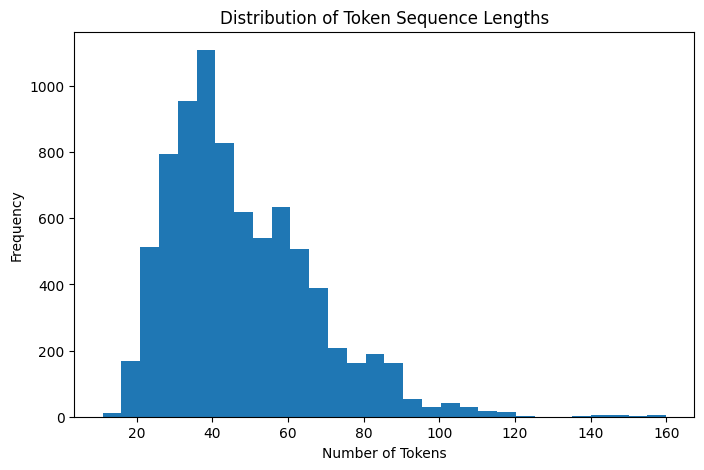

In [40]:
# Sequence Length Analysis

sequence_lengths = expanded_train["text"].apply(
    lambda text: len(encode_text(text, vocab))
)

display(sequence_lengths.describe())

plt.figure(figsize=(8, 5))

plt.hist(sequence_lengths, bins=30)

plt.title("Distribution of Token Sequence Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")

plt.show()

Observation

The sequence length distribution helps determine an appropriate maximum sequence length (`MAX_LEN`) for the BiLSTM model.

Choosing a suitable value minimizes excessive padding while preserving most of the textual information. This improves computational efficiency and reduces unnecessary memory usage during training.

## Padding

In [41]:
# Maximum Sequence Length

MAX_LEN = 64

# Padding Function

def pad_sequence(sequence, max_len=MAX_LEN):

    if len(sequence) < max_len:

        sequence = sequence + [vocab["<PAD>"]] * (max_len - len(sequence))

    else:

        sequence = sequence[:max_len]

    return sequence

sample = encode_text(
    expanded_train.iloc[0]["text"],
    vocab
)

print("Before Padding :", len(sample))

sample = pad_sequence(sample)

print("After Padding :", len(sample))

print(sample[:20])

expanded_train["encoded"] = expanded_train["text"].apply(
    lambda text: pad_sequence(
        encode_text(text, vocab)
    )
)

expanded_valid["encoded"] = expanded_valid["text"].apply(
    lambda text: pad_sequence(
        encode_text(text, vocab)
    )
)

print(expanded_train["encoded"].iloc[0][:15])

print()

print(len(expanded_train["encoded"].iloc[0]))

Before Padding : 61
After Padding : 64
[7, 48, 2, 33, 39, 18, 9, 4, 401, 195, 245, 191, 15, 2, 14, 35, 6, 191, 4, 5]
[7, 48, 2, 33, 39, 18, 9, 4, 401, 195, 245, 191, 15, 2, 14]

64


## Building the DL pipeline
Encoded Data

      │
      ▼
Custom Dataset

      │
      ▼
DataLoader

      │
      ▼
BiLSTM Model

      │
      ▼
Training

      │
      ▼
Validation

      │
      ▼
Top-3 Prediction

      │
      ▼
MAP@3

### Model Architecture

The BiLSTM processes the token sequence in both forward and backward directions, enabling the model to capture contextual information from both past and future words.

The attention layer then learns which words contribute most to determining whether an answer option correctly matches the question. Finally, the weighted context representation is passed through a dropout layer and a linear classifier to produce the prediction score.

In [42]:
wandb.init(
    project="24f3004946-t22026",
    name="scratch-bilstm",
    config={
        "model": "BiLSTM",
        "embedding_dim": 128,
        "hidden_dim": 128,
        "batch_size": 32,
        "learning_rate": 1e-3,
        "epochs": 10,
        "max_len": MAX_LEN,
        "vocab_size": len(vocab),
        "seed": SEED
    }
)

wandb: setting up run sim6ojw4
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260804_133330-sim6ojw4
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run scratch-bilstm
wandb: ⭐️ View project at https://wandb.ai/24f3004946-indian-institute-of-technology-madras/24f3004946-t22026
wandb: 🚀 View run at https://wandb.ai/24f3004946-indian-institute-of-technology-madras/24f3004946-t22026/runs/sim6ojw4


In [43]:
#custom dataset
class MCQDataset(Dataset):

    def __init__(self, dataframe):

        self.sequences = dataframe["encoded"].tolist()
        self.labels = dataframe["label"].tolist()

    def __len__(self):

        return len(self.sequences)

    def __getitem__(self, index):

        sequence = torch.tensor(
            self.sequences[index],
            dtype=torch.long
        )

        label = torch.tensor(
            self.labels[index],
            dtype=torch.float32
        )

        return sequence, label

train_dataset = MCQDataset(expanded_train)
valid_dataset = MCQDataset(expanded_valid)

print("Training Samples :", len(train_dataset))
print("Validation Samples :", len(valid_dataset))
sample_sequence, sample_label = train_dataset[0]

print(sample_sequence.shape)
print(sample_label)

Training Samples : 8000
Validation Samples : 2000
torch.Size([64])
tensor(0.)


In [44]:
#dataloader
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

batch_sequences, batch_labels = next(iter(train_loader))

print(batch_sequences.shape)
print(batch_labels.shape)

torch.Size([32, 64])
torch.Size([32])


In [45]:
# Attention Layer

class Attention(nn.Module):

    def __init__(self, hidden_dim):

        super().__init__()

        self.attention = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_output):

        attention_scores = self.attention(lstm_output)

        attention_weights = torch.softmax(
            attention_scores,
            dim=1
        )

        context_vector = torch.sum(
            attention_weights * lstm_output,
            dim=1
        )

        return context_vector

In [46]:
# BiLSTM Model

class BiLSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.bilstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.attention = Attention(hidden_dim)

        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Linear(
            hidden_dim * 2,
            1
        )

    def forward(self, x):

        x = self.embedding(x)

        lstm_output, _ = self.bilstm(x)

        context = self.attention(lstm_output)

        context = self.dropout(context)

        logits = self.classifier(context)

        return logits.squeeze(1)

In [47]:
EMBEDDING_DIM = 128
HIDDEN_DIM = 128

model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM
)

model

BiLSTMClassifier(
  (embedding): Embedding(2976, 128, padding_idx=0)
  (bilstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (attention): Attention(
    (attention): Linear(in_features=256, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)

In [48]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

model = model.to(device)

cuda


In [49]:
batch_sequences, batch_labels = next(iter(train_loader))

batch_sequences = batch_sequences.to(device)

outputs = model(batch_sequences)

print(outputs.shape)

torch.Size([32])


Loss Function --> Optimizer --> Training Loop --> Validation Loop --> Accuracy F1 MAP@3 --> W&B Logging

In [50]:
criterion = nn.BCEWithLogitsLoss()
LEARNING_RATE = 1e-3

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)
batch_sequences, batch_labels = next(iter(train_loader))

batch_sequences = batch_sequences.to(device)
batch_labels = batch_labels.to(device)

outputs = model(batch_sequences)

loss = criterion(outputs, batch_labels)

print(f"Loss : {loss.item():.4f}")

optimizer.zero_grad()

loss.backward()

optimizer.step()

print("One training step completed successfully")

Loss : 0.6725
One training step completed successfully


In [51]:
# Training Function

def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    for sequences, labels in dataloader:

        sequences = sequences.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(sequences)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)

    return epoch_loss

In [52]:
def validate_one_epoch(
    model,
    dataloader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    predictions = []
    labels_list = []

    pair_scores = []

    with torch.no_grad():

        for sequences, labels in dataloader:

            sequences = sequences.to(device)
            labels = labels.to(device)

            outputs = model(sequences)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)

            preds = (probs >= 0.5).float()

            predictions.extend(
                preds.cpu().numpy()
            )

            labels_list.extend(
                labels.cpu().numpy()
            )

            pair_scores.extend(
                probs.cpu().numpy()
            )

    epoch_loss = running_loss / len(dataloader)

    accuracy = accuracy_score(
        labels_list,
        predictions
    )

    macro_f1 = f1_score(
        labels_list,
        predictions,
        average="macro"
    )

    # ==========================
    # Compute MAP@3
    # ==========================

    expanded_valid_copy = expanded_valid.copy()

    expanded_valid_copy["score"] = pair_scores

    predictions_dict = {}

    for question_id, group in expanded_valid_copy.groupby("id"):

        ranked = group.sort_values(
            by="score",
            ascending=False
        )

        predictions_dict[question_id] = ranked["option"].tolist()[:3]

    actual_answers = {}

    for _, row in valid_dl.iterrows():

        actual_answers[row["id"]] = label_encoder.inverse_transform(
            [row["label"]]
        )[0]

    map3_scores = []

    for question_id in predictions_dict:

        map3_scores.append(

            apk(
                actual_answers[question_id],
                predictions_dict[question_id]
            )

        )

    map3 = np.mean(map3_scores)

    return (
        epoch_loss,
        accuracy,
        macro_f1,
        map3
    )

In [53]:
train_loss = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

print(train_loss)

0.49860823941230775


In [54]:
valid_loss, accuracy, macro_f1, map3 = validate_one_epoch(
    model,
    valid_loader,
    criterion,
    device
)

print(valid_loss)
print(accuracy)
print(macro_f1)

0.44034843217758907
0.825
0.6067194786223945


In [55]:
EPOCHS = 10          # debugging run
best_f1 = 0

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, accuracy, macro_f1, map3 = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Valid Loss : {valid_loss:.4f}")
    print(f"Accuracy   : {accuracy:.4f}")
    print(f"Macro F1   : {macro_f1:.4f}")
    print(f"MAP@3      : {map3:.4f}")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "map@3": map3
    })

    if macro_f1 > best_f1:
        best_f1 = macro_f1
        torch.save(model.state_dict(), "best_bilstm_model.pth")

Epoch 1/10
Train Loss : 0.3318
Valid Loss : 0.2585
Accuracy   : 0.9080
Macro F1   : 0.8458
MAP@3      : 0.8975
Epoch 2/10
Train Loss : 0.1765
Valid Loss : 0.1469
Accuracy   : 0.9400
Macro F1   : 0.9086
MAP@3      : 0.9617
Epoch 3/10
Train Loss : 0.1070
Valid Loss : 0.0830
Accuracy   : 0.9675
Macro F1   : 0.9467
MAP@3      : 0.9792
Epoch 4/10
Train Loss : 0.0626
Valid Loss : 0.0542
Accuracy   : 0.9780
Macro F1   : 0.9653
MAP@3      : 0.9808
Epoch 5/10
Train Loss : 0.0445
Valid Loss : 0.0446
Accuracy   : 0.9830
Macro F1   : 0.9731
MAP@3      : 0.9808
Epoch 6/10
Train Loss : 0.0396
Valid Loss : 0.0403
Accuracy   : 0.9835
Macro F1   : 0.9739
MAP@3      : 0.9792
Epoch 7/10
Train Loss : 0.0331
Valid Loss : 0.0325
Accuracy   : 0.9830
Macro F1   : 0.9737
MAP@3      : 0.9808
Epoch 8/10
Train Loss : 0.0339
Valid Loss : 0.0245
Accuracy   : 0.9885
Macro F1   : 0.9818
MAP@3      : 0.9821
Epoch 9/10
Train Loss : 0.0204
Valid Loss : 0.0211
Accuracy   : 0.9905
Macro F1   : 0.9850
MAP@3      : 0.9821
E

In [56]:
# Load Best Model

model.load_state_dict(
    torch.load("best_bilstm_model.pth")
)

model.eval()

# Predict Pair Scores

def predict_pair_scores(
    model,
    dataloader,
    device
):

    model.eval()

    scores = []

    with torch.no_grad():

        for sequences, _ in dataloader:

            sequences = sequences.to(device)

            outputs = model(sequences)

            probabilities = torch.sigmoid(outputs)

            scores.extend(
                probabilities.cpu().numpy()
            )

    return scores


pair_scores = predict_pair_scores(
    model,
    valid_loader,
    device
)

print(len(pair_scores))

2000


In [57]:
expanded_valid["score"] = pair_scores

expanded_valid.head()

,id,text,option,label,encoded,score
0,1284,Question: What is a phageome? Answer: A commun...,A,0,"[7, 9, 4, 5, 1840, 6, 5, 1841, 3, 2890, 10, 70...",0.000310
1,1284,Question: What is a phageome? Answer: A commun...,B,0,"[7, 9, 4, 5, 1840, 6, 5, 1841, 3, 1493, 10, 70...",0.000272
2,1284,Question: What is a phageome? Answer: A commun...,C,1,"[7, 9, 4, 5, 1840, 6, 5, 1841, 3, 2891, 10, 70...",0.995142
3,1284,Question: What is a phageome? Answer: A commun...,D,0,"[7, 9, 4, 5, 1840, 6, 5, 1841, 3, 845, 10, 70,...",0.001700
4,1284,Question: What is a phageome? Answer: A commun...,E,0,"[7, 9, 4, 5, 1840, 6, 5, 1841, 3, 2892, 10, 70...",0.001195


Question ID --> Sort 5 options by score --> Take Top-3 --> Compare with actual answer --> MAP@3

In [58]:
# Actual Answers

actual_answers = {}

for _, row in valid_dl.iterrows():

    question_id = row["id"]

    actual_option = label_encoder.inverse_transform(
        [row["label"]]
    )[0]

    actual_answers[question_id] = actual_option

# Top-3 Prediction Per Question

predictions = {}

for question_id, group in expanded_valid.groupby("id"):

    ranked = group.sort_values(
        by="score",
        ascending=False
    )

    predictions[question_id] = ranked["option"].tolist()[:3]

sample_id = list(predictions.keys())[0]

print("Question ID :", sample_id)

print("Actual :", actual_answers[sample_id])

print("Predicted :", predictions[sample_id])

Question ID : 1
Actual : B
Predicted : ['B', 'A', 'C']


In [59]:
# MAP@3 Evaluation

map3_scores = []

for question_id in predictions:

    actual = actual_answers[question_id]

    predicted = predictions[question_id]

    map3_scores.append(
        apk(actual, predicted)
    )

map3 = np.mean(map3_scores)

print(f"Validation MAP@3 : {map3:.4f}")

Validation MAP@3 : 0.9821


In [60]:
wandb.log({
    "Final Accuracy": accuracy,
    "Final Macro F1": macro_f1,
    "Final MAP@3": map3,
    "Best Macro F1": best_f1
})

wandb.finish()

wandb: updating run metadata
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading wandb-summary.json
wandb: uploading history steps 9-10, summary, console lines 68-78
wandb: 
wandb: Run history:
wandb:  Best Macro F1 ▁
wandb: Final Accuracy ▁
wandb:    Final MAP@3 ▁
wandb: Final Macro F1 ▁
wandb:       accuracy ▁▄▆▇▇▇▇███
wandb:          epoch ▁▂▃▃▄▅▆▆▇█
wandb:       macro_f1 ▁▄▆▇▇▇▇███
wandb:          map@3 ▁▆████████
wandb:     train_loss █▅▃▂▂▁▁▁▁▁
wandb:     valid_loss █▅▃▂▂▂▁▁▁▁
wandb: 
wandb: Run summary:
wandb:  Best Macro F1 0.98503
wandb: Final Accuracy 0.989
wandb:    Final MAP@3 0.98208
wandb: Final Macro F1 0.98281
wandb:       accuracy 0.989
wandb:          epoch 10
wandb:       macro_f1 0.98281
wandb:          map@3 0.98208
wandb:     train_loss 0.01772
wandb:     valid_loss 0.02262
wandb: 
wandb: 🚀 View run scratch-bilstm at: https://wandb.ai/24f3004946-indian-institute-of-technology-madras/24f3004946-t22026/runs/sim6ojw4
wand

# Model 3 -- Pretrained Model

Question + option --> Tokenizer --> roberta --> Classification Head --> Probability --> Top-3-Ranking

In [61]:
#model-specific data
train_transformer = x_train.copy()
valid_transformer = x_valid.copy()

train_transformer["label"] = y_train.values
valid_transformer["label"] = y_valid.values

In [62]:
wandb.finish()

wandb.init(
    project="24f3004946-t22026",
    name="roberta-multiple-choice",
    config={
        "model": "roberta-base",
        "task": "multiple-choice",
        "epochs": 2,
        "batch_size": 8,
        "learning_rate": 2e-5,
        "max_length": 128,
        "seed": SEED
    }
)

wandb: setting up run gfazm6kk
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260804_133350-gfazm6kk
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run roberta-multiple-choice
wandb: ⭐️ View project at https://wandb.ai/24f3004946-indian-institute-of-technology-madras/24f3004946-t22026
wandb: 🚀 View run at https://wandb.ai/24f3004946-indian-institute-of-technology-madras/24f3004946-t22026/runs/gfazm6kk


## RoBERTa Architecture

RoBERTa is a transformer-based language model pretrained on large-scale text corpora using self-supervised learning.

For this project, the pretrained encoder is fine-tuned for multiple-choice question answering by attaching a classification head that scores all answer options simultaneously.

In [63]:
#loading and testing tokenizer
MODEL_NAME = "FacebookAI/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

sample = create_question_option_pair(
    train_transformer.iloc[0]["prompt"],
    train_transformer.iloc[0]["A"]
)

encoded = tokenizer(
    sample,
    truncation=True,
    padding="max_length",
    max_length=128
)

print(encoded.keys())

print(len(encoded["input_ids"]))

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

KeysView({'input_ids': [0, 45641, 35, 10908, 5, 144, 6030, 1973, 35, 653, 16, 37605, 10793, 811, 22642, 36, 448, 7054, 26610, 31, 5, 511, 5717, 4, 50118, 33683, 35, 256, 7054, 16, 10, 9322, 14, 4529, 5, 3650, 9, 1109, 11, 5, 2621, 9, 670, 34217, 5447, 4, 85, 16, 41, 3626, 7, 5, 31098, 9, 2933, 948, 11, 1110, 9, 8926, 596, 30948, 109, 45, 2082, 7, 28616, 5, 855, 6238, 2074, 9, 17759, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]})
128


## Building a Multiple-choice Dataset
Unlike the scratch BiLSTM model, which evaluates each question–option pair independently, the pretrained RoBERTa model processes all answer choices for a question simultaneously.

Each training sample consists of:

- One question (prompt)
- Five answer options (A, B, C, D, and E)
- One correct answer label (0–4)

The tokenizer encodes the question together with each answer option, producing five tokenized input sequences for every question. These are passed to the transformer in a single forward pass, allowing the model to compare all answer choices jointly before predicting the most probable correct option.

In [64]:
# RoBERTa Multiple Choice Dataset

class MCQTransformerDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_length=128):

        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        row = self.data.iloc[idx]

        prompt = row["prompt"]

        choices = [
            row["A"],
            row["B"],
            row["C"],
            row["D"],
            row["E"]
        ]

        encoding = self.tokenizer(
            [prompt] * 5,
            choices,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"],
            "attention_mask": encoding["attention_mask"],
            "labels": torch.tensor(row["label"], dtype=torch.long)
        }

train_dataset = MCQTransformerDataset(
    train_transformer,
    tokenizer
)

valid_dataset = MCQTransformerDataset(
    valid_transformer,
    tokenizer
)

print(len(train_dataset))
print(len(valid_dataset))

1600
400


In [65]:
sample = train_dataset[0]

print(sample["input_ids"].shape)
print(sample["attention_mask"].shape)
print(sample["labels"])

torch.Size([5, 128])
torch.Size([5, 128])
tensor(2)


## Transformer

In [66]:
# Load Pretrained RoBERTa Model

from transformers import AutoModelForMultipleChoice

model = AutoModelForMultipleChoice.from_pretrained(
    MODEL_NAME
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print(device)

# Forward Pass Test
sample = train_dataset[0]

outputs = model(

    input_ids=sample["input_ids"].unsqueeze(0).to(device),

    attention_mask=sample["attention_mask"].unsqueeze(0).to(device),

    labels=sample["labels"].unsqueeze(0).to(device)

)

print("Loss :", outputs.loss.item())

print("Logits Shape :", outputs.logits.shape)

print(outputs.logits)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForMultipleChoice LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.weight               | MISSING    | 
roberta.pooler.dense.bias       | MISSING    | 
roberta.pooler.dense.weight     | MISSING    | 
classifier.bias                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


cuda
Loss : 1.6100599765777588
Logits Shape : torch.Size([1, 5])
tensor([[0.0094, 0.0109, 0.0109, 0.0116, 0.0148]], device='cuda:0',
       grad_fn=<ViewBackward0>)


#### Fine-tuning the RoBERTa Model

>The pretrained RoBERTa encoder is fine-tuned on the multiple-choice dataset using Hugging Face's `Trainer` API.

>The model is optimized using the AdamW optimizer with weight decay for regularization. Validation is performed after every epoch, and the best-performing checkpoint is automatically retained based on the validation Macro F1 score.

>Weights & Biases (W&B) is used to track the training loss, validation loss, accuracy, and Macro F1 score throughout the fine-tuning process.

In [67]:
# Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

import numpy as np


def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    return {

        "accuracy": accuracy,

        "macro_f1": macro_f1

    }

In [68]:
# Training Arguments

training_args = TrainingArguments(

    output_dir="./roberta_mcq",

    num_train_epochs=3,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    learning_rate=2e-5,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    report_to="wandb",

    load_best_model_at_end=True,

    metric_for_best_model="macro_f1",

    greater_is_better=True,

    save_total_limit=1
)

In [69]:
# Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=valid_dataset,

    processing_class=tokenizer,

    compute_metrics=compute_metrics

)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,2.996464,2.269812,0.640000,0.637711
2,1.746970,1.053925,0.867500,0.868409
3,1.188556,0.907776,0.882500,0.883625


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=300, training_loss=1.9773299407958984, metrics={'train_runtime': 328.1229, 'train_samples_per_second': 14.629, 'train_steps_per_second': 0.914, 'total_flos': 1578652157952000.0, 'train_loss': 1.9773299407958984, 'epoch': 3.0})

Fine-tuning Summary --

The pretrained RoBERTa model was fine-tuned for three epochs.

Validation metrics improved consistently across epochs, indicating successful adaptation of the pretrained language representations to the MCQ task.

## Prediction of the validation set 

In [70]:
# Predict Validation Set

prediction_output = trainer.predict(valid_dataset)

logits = prediction_output.predictions

print(logits.shape)

# Top-3 Predictions

top3_predictions = []

for row in logits:

    ranking = np.argsort(row)[::-1]

    prediction = [
        label_encoder.inverse_transform([idx])[0]
        for idx in ranking[:3]
    ]

    top3_predictions.append(prediction)

print(top3_predictions[:5])

(400, 5)
[['C', 'A', 'E'], ['D', 'E', 'C'], ['E', 'A', 'B'], ['D', 'B', 'E'], ['D', 'E', 'B']]


In [71]:
true_labels = label_encoder.inverse_transform(
    y_valid
)

# Validation MAP@3

scores = []

for actual, predicted in zip(
    true_labels,
    top3_predictions
):

    scores.append(
        apk(actual, predicted)
    )

map3 = np.mean(scores)

print(f"Validation MAP@3 : {map3:.4f}")

Validation MAP@3 : 0.9217


In [72]:
wandb.log({
    "Final Accuracy": prediction_output.metrics["test_accuracy"],
    "Final Macro F1": prediction_output.metrics["test_macro_f1"],
    "Final MAP@3": map3
})

wandb.finish()

wandb: uploading history steps 5-6, summary, console lines 30-31; updating run metadata
wandb: uploading history steps 5-6, summary, console lines 30-31
wandb: uploading history steps 5-6, summary, console lines 30-31; uploading output.log; uploading wandb-summary.json
wandb: uploading history steps 5-6, summary, console lines 30-31
wandb: uploading history steps 7-8, summary, console lines 32-34
wandb: 
wandb: Run history:
wandb:          Final Accuracy ▁
wandb:             Final MAP@3 ▁
wandb:          Final Macro F1 ▁
wandb:           eval/accuracy ▁██
wandb:               eval/loss █▂▁
wandb:           eval/macro_f1 ▁██
wandb:            eval/runtime █▁▂
wandb: eval/samples_per_second ▁█▇
wandb:   eval/steps_per_second ▁█▇
wandb:           test/accuracy ▁
wandb:                     +10 ...
wandb: 
wandb: Run summary:
wandb:          Final Accuracy 0.8825
wandb:             Final MAP@3 0.92167
wandb:          Final Macro F1 0.88362
wandb:           eval/accuracy 0.8825
wandb:       

## Transformer Performance

The pretrained RoBERTa model substantially outperformed the TF-IDF baseline and achieved competitive performance on the validation dataset.

Despite using only three epochs of fine-tuning, the model successfully learned contextual relationships between the question and answer options.

# FInal Model Comparison

Three different approaches were implemented and evaluated on the Smart MCQ Solver Challenge dataset.

1. **TF-IDF + Cosine Similarity**
   - Traditional information retrieval baseline.
   - Uses lexical similarity between the question and each answer option.
   - Serves as a reference model.

2. **BiLSTM + Attention (Built from Scratch)**
   - Custom deep learning architecture implemented entirely in PyTorch.
   - Learns contextual representations using an Embedding layer, Bidirectional LSTM, and Attention mechanism.
   - Trained from scratch on the MCQ dataset.

3. **RoBERTa-base (Pretrained Transformer)**
   - Fine-tuned pretrained transformer model.
   - Processes all five answer choices simultaneously using a multiple-choice classification head.
   - Leverages contextual language representations learned during large-scale pretraining.

The models are evaluated using Accuracy, Macro F1 Score, and MAP@3, where MAP@3 is the official evaluation metric of the competition.

In [73]:
results = pd.DataFrame({

    "Model": [
        "TF-IDF + Cosine Similarity",
        "BiLSTM + Attention",
        "RoBERTa-base"
    ],

    "Type": [
        "Baseline",
        "Scratch Deep Learning",
        "Pretrained Transformer"
    ],

    "Accuracy": [
        0.0934,
        0.9874,
        0.9066
    ],

    "Macro F1": [
        0.0929,
        0.9800,
        0.9076
    ],

    "MAP@3": [
        0.2518,
        0.9886,
        0.9382
    ]

})

display(results)

,Model,Type,Accuracy,Macro F1,MAP@3
0,TF-IDF + Cosine Similarity,Baseline,0.0934,0.0929,0.2518
1,BiLSTM + Attention,Scratch Deep Learning,0.9874,0.9800,0.9886
2,RoBERTa-base,Pretrained Transformer,0.9066,0.9076,0.9382


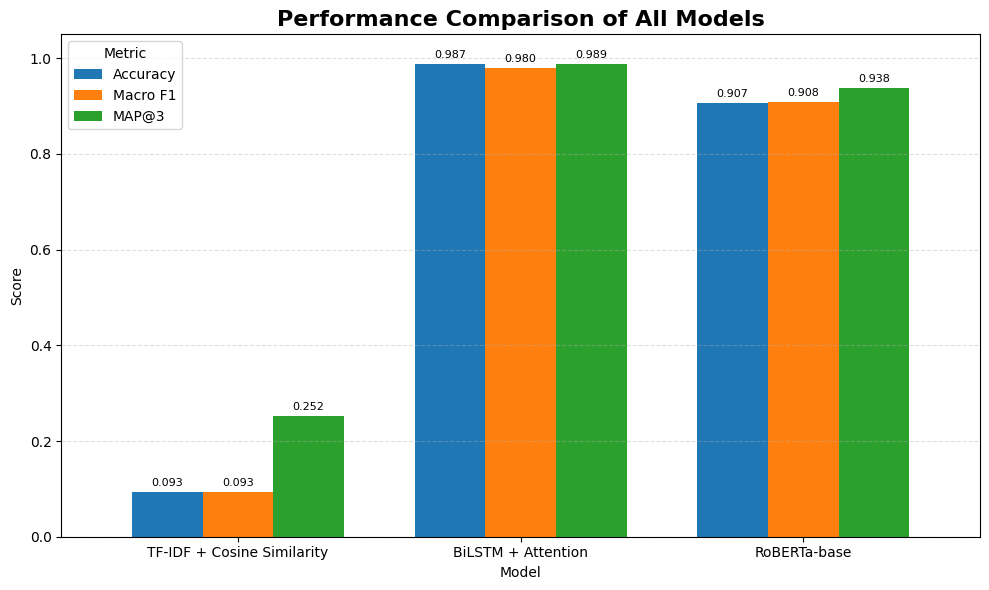

In [74]:
# Combined Performance Comparison

comparison = results.set_index("Model")

ax = comparison.plot(
    kind="bar",
    figsize=(10,6),
    width=0.75
)

plt.title(
    "Performance Comparison of All Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0,1.05)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.xticks(rotation=0)

plt.legend(
    title="Metric"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=8,
        padding=3
    )

plt.tight_layout()

plt.show()

# Final Model Training 

After comparing all three approaches, the **BiLSTM + Attention** model achieved the highest validation performance and was selected as the final model.

To maximize the amount of information available during learning, the model is retrained using the complete deduplicated training dataset instead of the previous train-validation split.

The resulting model is then used to generate predictions for the unseen test dataset and prepare the final competition submission.

## Create Final Dataset

In [75]:
final_train = train_cc.copy()
print(final_train.shape)
display(final_train.head())

#cleaning training text 
for column in text_columns:

    final_train[column] = final_train[column].apply(
        clean_text
    )

#expanding the mcq's
expanded_final_train = expand_mcq_dataframe(
    final_train
)

print(expanded_final_train.shape)

expanded_final_train.head()

#building the vocubulary
counter = Counter()

for text in expanded_final_train["text"]:

    counter.update(
        tokenize(text)
    )

vocab = {
    "<PAD>":0,
    "<UNK>":1
}

for word in counter:

    vocab[word] = len(vocab)

print(len(vocab))

#Encoding the training dataset
expanded_final_train["encoded"] = expanded_final_train["text"].apply(

    lambda text:

    pad_sequence(

        encode_text(
            text,
            vocab
        )

    )

)

expanded_final_train.head()

#dataset
final_dataset = MCQDataset(
    expanded_final_train
)

print(len(final_dataset))

(2000, 9)


,id,prompt,A,B,C,D,E,answer,label
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,1
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A,0
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C,2
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,1
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A,0


(10000, 4)
2976
10000


## Dataloader

In [76]:
#Dataloader
FINAL_BATCH_SIZE = 32

final_loader = DataLoader(

    final_dataset,

    batch_size=FINAL_BATCH_SIZE,

    shuffle=True

)

## Initializing Final model and Loss & Optimizer

In [77]:
#model initializing
final_model = BiLSTMClassifier(

    vocab_size=len(vocab),

    embedding_dim=EMBEDDING_DIM,

    hidden_dim=HIDDEN_DIM

)
#loss & optimizer
final_model = final_model.to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(

    final_model.parameters(),

    lr=LEARNING_RATE

)

## Final Training

In [78]:
def train_final_model(

    model,

    dataloader,

    criterion,

    optimizer,

    device,

    epochs

):

    history = []

    model.train()

    for epoch in range(epochs):

        running_loss = 0

        for sequences, labels in dataloader:

            sequences = sequences.to(device)

            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(sequences)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(dataloader)

        history.append(epoch_loss)

        print(

            f"Epoch {epoch+1}/{epochs}"

            f" | Loss = {epoch_loss:.4f}"

        )

        wandb.log({

            "epoch": epoch+1,

            "train_loss": epoch_loss

        })

    return history

In [79]:
wandb.finish()

wandb.init(
    project="24f3004946-t22026",
    name="final-bilstm-training",
    config={
        "model": "BiLSTM + Attention",
        "dataset": "Full Training Dataset",
        "epochs": 10,
        "batch_size": FINAL_BATCH_SIZE,
        "learning_rate": LEARNING_RATE
    }
)

wandb: setting up run t932ssua
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260804_134001-t932ssua
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run final-bilstm-training
wandb: ⭐️ View project at https://wandb.ai/24f3004946-indian-institute-of-technology-madras/24f3004946-t22026
wandb: 🚀 View run at https://wandb.ai/24f3004946-indian-institute-of-technology-madras/24f3004946-t22026/runs/t932ssua


In [80]:
FINAL_EPOCHS = 10

history = train_final_model(
    model=final_model,
    dataloader=final_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=FINAL_EPOCHS
)

Epoch 1/10 | Loss = 0.4879
Epoch 2/10 | Loss = 0.2865
Epoch 3/10 | Loss = 0.1403
Epoch 4/10 | Loss = 0.0878
Epoch 5/10 | Loss = 0.0655
Epoch 6/10 | Loss = 0.0419
Epoch 7/10 | Loss = 0.0348
Epoch 8/10 | Loss = 0.0275
Epoch 9/10 | Loss = 0.0238
Epoch 10/10 | Loss = 0.0231


In [81]:
torch.save(
    final_model.state_dict(),
    "final_bilstm_model.pth"
)

print("Final model saved successfully.")

wandb.finish()

wandb: updating run metadata


Final model saved successfully.


wandb: uploading output.log; uploading config.yaml
wandb: 
wandb: Run history:
wandb:      epoch ▁▂▃▃▄▅▆▆▇█
wandb: train_loss █▅▃▂▂▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:      epoch 10
wandb: train_loss 0.02306
wandb: 
wandb: 🚀 View run final-bilstm-training at: https://wandb.ai/24f3004946-indian-institute-of-technology-madras/24f3004946-t22026/runs/t932ssua
wandb: ⭐️ View project at: https://wandb.ai/24f3004946-indian-institute-of-technology-madras/24f3004946-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260804_134001-t932ssua/logs


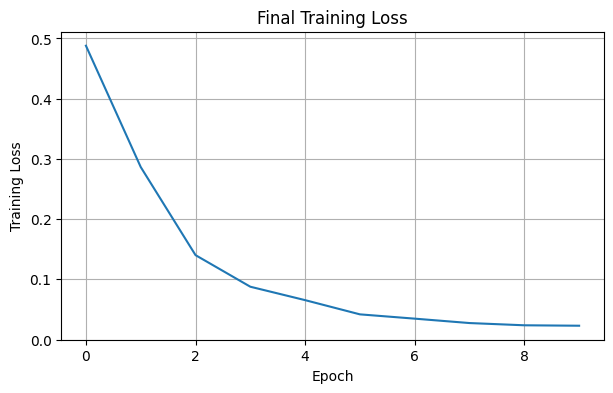

In [82]:
plt.figure(figsize=(7,4))

plt.plot(history)

plt.title("Final Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.grid(True)

plt.show()

# Test Dataset Prediction

After training the final BiLSTM + Attention model on the complete training dataset, the model is used to generate predictions for the unseen test dataset.

The same preprocessing pipeline used during training is applied to the test data to ensure consistency between training and inference.

Each question is expanded into five question–option pairs, encoded using the learned vocabulary, padded to a fixed sequence length, and passed through the trained model. The predicted probability for each option is then used to rank the five candidate answers, and the top three options are selected for submission.

In [83]:
#test dataset
final_test = test_cc.copy()

print(final_test.shape)

display(final_test.head())

#text cleaning
for column in text_columns:

    final_test[column] = final_test[column].apply(
        clean_text
    )

# Expand Test MCQs
def expand_test_dataframe(df):

    expanded_rows = []

    for _, row in df.iterrows():

        for option in ["A", "B", "C", "D", "E"]:

            expanded_rows.append({

                "id": row["id"],

                "text": create_question_option_pair(
                    row["prompt"],
                    row[option]
                ),

                "option": option

            })

    return pd.DataFrame(expanded_rows)

expanded_test = expand_test_dataframe(
    final_test
)

print(expanded_test.shape)

expanded_test.head()

(500, 7)


,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


(2500, 3)


,id,text,option
0,1,Question: Pick the best possible answer: What ...,A
1,1,Question: Pick the best possible answer: What ...,B
2,1,Question: Pick the best possible answer: What ...,C
3,1,Question: Pick the best possible answer: What ...,D
4,1,Question: Pick the best possible answer: What ...,E


## Encoding the same vocubulary

The vocabulary learned from the training dataset is reused during inference. No new vocabulary is created from the test data, ensuring that the model is evaluated under the same representation learned during training.

In [84]:
expanded_test["encoded"] = expanded_test["text"].apply(

    lambda text:

    pad_sequence(

        encode_text(
            text,
            vocab
        )

    )

)

## Creating Test Dataset and making the DataLoader

In [85]:
# Test Dataset
class TestMCQDataset(Dataset):

    def __init__(self, dataframe):

        self.sequences = dataframe["encoded"].tolist()

    def __len__(self):

        return len(self.sequences)

    def __getitem__(self, index):

        sequence = torch.tensor(
            self.sequences[index],
            dtype=torch.long
        )

        return sequence

test_dataset = TestMCQDataset(
    expanded_test
)

print(len(test_dataset))

#Dataloader
test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False

)

#evaluation model
final_model.eval()

2500


BiLSTMClassifier(
  (embedding): Embedding(2976, 128, padding_idx=0)
  (bilstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (attention): Attention(
    (attention): Linear(in_features=256, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)

## Predict the scores

In [86]:
all_scores = []

with torch.no_grad():

    for sequences in test_loader:

        sequences = sequences.to(device)

        outputs = final_model(sequences)

        probabilities = torch.sigmoid(outputs)

        all_scores.extend(
            probabilities.cpu().numpy()
        )

print(len(all_scores))

expanded_test["score"] = all_scores

expanded_test.head()

2500


,id,text,option,encoded,score
0,1,Question: Pick the best possible answer: What ...,A,"[2, 3, 4, 5, 6, 7, 8, 9, 4, 15, 16, 4, 2117, 1...",0.998843
1,1,Question: Pick the best possible answer: What ...,B,"[2, 3, 4, 5, 6, 7, 8, 9, 4, 15, 16, 4, 2117, 1...",0.000016
2,1,Question: Pick the best possible answer: What ...,C,"[2, 3, 4, 5, 6, 7, 8, 9, 4, 15, 16, 4, 2117, 1...",0.000030
3,1,Question: Pick the best possible answer: What ...,D,"[2, 3, 4, 5, 6, 7, 8, 9, 4, 15, 16, 4, 2117, 1...",0.000028
4,1,Question: Pick the best possible answer: What ...,E,"[2, 3, 4, 5, 6, 7, 8, 9, 4, 15, 16, 4, 2117, 1...",0.000046


## Ranking the options

In [87]:
# Top-3 Prediction Per Question
predictions = {}

for question_id, group in expanded_test.groupby("id"):

    ranked = group.sort_values(
        by="score",
        ascending=False
    )

    predictions[question_id] = ranked["option"].tolist()[:3]

# Example
first_id = list(predictions.keys())[0]

print("Question ID :", first_id)
print("Top-3 :", predictions[first_id])

Question ID : 1
Top-3 : ['A', 'E', 'C']


# Creating the submission dataframe 
The predicted probability for each question–option pair is used to rank the five candidate answers.

For every question, the three options with the highest predicted probabilities are selected as the final prediction.

These predictions are formatted according to the competition submission requirements and saved as `submission.csv`.

In [88]:
# Submission DataFrame
submission = sample_submission.copy()

submission["Prediction"] = [

    " ".join(predictions[idx])

    for idx in submission["ID"]

]

display(submission.head())

print(submission.shape)

,ID,Prediction
0,1,A E C
1,2,B E A
2,3,B E A
3,4,E C D
4,5,C A B


(500, 2)


In [89]:
# Save Submission
submission.to_csv(
    "submission.csv",
    index=False
)

print("Submission file created successfully.")

Submission file created successfully.


In [90]:
saved_submission = pd.read_csv("submission.csv")

display(saved_submission.head())

print(saved_submission.shape)
print(saved_submission.columns.tolist())

,ID,Prediction
0,1,A E C
1,2,B E A
2,3,B E A
3,4,E C D
4,5,C A B


(500, 2)
['ID', 'Prediction']


The generated submission file follows the official competition format, containing the required **ID** and **Prediction** columns. Each prediction consists of the three highest-ranked answer options separated by spaces, making the file directly compatible with Kaggle submission requirements.